<a href="https://colab.research.google.com/github/Laboratorio-de-Analise-de-Dados/img-PEP/blob/main/1_Retirada_excesso_pixel.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
pip install util-gfsilveira

Importação de Bibliotecas

In [ ]:
import os #organizador de pasta
import numpy as np #estruturação dos dados
import matplotlib.pyplot as plt #plot gráfico
import seaborn as sns #plot gráfico
from PIL import Image #visualização de img
import pandas as pd #estruturação dos dados
from util import meus_uteis, timeProcess
import joblib #convertendo imagens em valores numéricos .gz

Salvando essas pastas de imagens em formato de pastas em formato de comando linux.

In [ ]:
!apt-get install tree

Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
The following NEW packages will be installed:
  tree
0 upgraded, 1 newly installed, 0 to remove and 45 not upgraded.
Need to get 47.9 kB of archives.
After this operation, 116 kB of additional disk space will be used.
Get:1 http://archive.ubuntu.com/ubuntu jammy/universe amd64 tree amd64 2.0.2-1 [47.9 kB]
Fetched 47.9 kB in 1s (35.4 kB/s)
Selecting previously unselected package tree.
(Reading database ... 121918 files and directories currently installed.)
Preparing to unpack .../tree_2.0.2-1_amd64.deb ...
Unpacking tree (2.0.2-1) ...
Setting up tree (2.0.2-1) ...
Processing triggers for man-db (2.10.2-1) ...


Carregando a lista de imagens:

In [ ]:
!tree ./drive/MyDrive/teste/imagem_conjunto/ -af >> estrutura_diretorio_Eloiza_25_01_24.txt

In [ ]:
#!cat /content/estrutura_diretorio_Eloiza_25_01_24.txt

Função criada para "limpar" símbolos da lista

In [ ]:
def limpa_lista_img(path_img: str) -> str:
    path_img = path_img.replace("│\xa0\xa0", "")
    path_img = path_img.replace("├──", "")
    path_img = path_img.replace("└──", "")
    path_img = path_img.replace("\n", "")
    path_img = path_img.strip()
 #   path_img = path_img.replace("./", "./data/")
    return path_img

Abrindo os arquivos:

In [ ]:
#abrindo o arquivo:
with open("/content/drive/MyDrive/teste/estrutura_diretorio_Eloiza_25_01_24.txt", "r") as file:
    lista_arquivos = file.readlines()
lista_arquivos = [limpa_lista_img(i) for i in lista_arquivos if ".tif" in i] #laço para chamar os arquivos em formato tif
#lista_arquivos #listando os 3 primeiros arquivos
len(lista_arquivos)

561

#Chamando apenas as imagens dentro do GTS CHO-745:

In [ ]:
#Filtrando as imagens GTS CHO 745
lista_arquivos_gst = [i for i in lista_arquivos if "/CHO-745/GTS/" in i]
lista_arquivos_fluo = [i for i in lista_arquivos_gst if "ch01.tif" in i]

#lista_arquivos_fluo[:3]
len(lista_arquivos_fluo)

21

Abrindo a primeira imagem de GTS CHO 745:

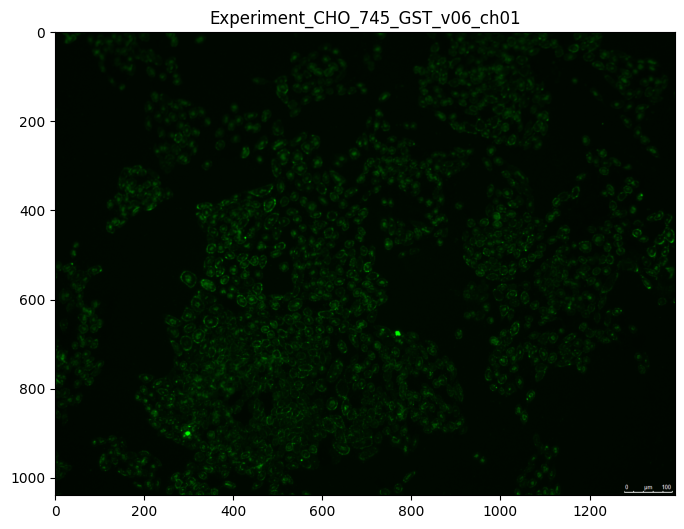

In [ ]:
path = lista_arquivos_fluo[15] #chamando a primeira imagem
img = Image.open(path) #abrinado a primeira imagem

plt.figure(figsize=(8,8)) #tamanho da imagem
plt.imshow(img) #abrindo a imagem
plt.title(path[50:-4]) #título recortando o nome do título que corresponde o caminho da imagem[50:-4]
plt.show()

Convertendo a imagem escolhida para um DataFrame

In [ ]:
#definindo uma função que converte as imagens em matriz numpy
def img_to_df(img) -> pd.DataFrame:
  img_array = np.array(img, dtype="float64")/255 #organizando o tamanho da matriz
  img_df = pd.DataFrame(columns=["red"], data=img_array[:,:,0].reshape(-1,1)) #aqui a cor vermelha da imagem foi anulada e os valores entraram como zero na coluna da df
  img_df["green"] = img_array[:,:,1].reshape(-1,1) # mantendo apenas a camada verde (de interesse)
  img_df["blue"] = img_array[:,:,2].reshape(-1,1) #mesma coisa que foi feita na camada vermelha foi feita com a azul

  return img_df

In [ ]:
img_df_first = img_to_df(img=img) #chamando a função criada e como parâmetro está sendo passado a imagem organizada na pasta lá em cima.
img_df_first.head()

,red,green,blue
0,0.0,0.031373,0.0
1,0.0,0.027451,0.0
2,0.0,0.023529,0.0
3,0.0,0.031373,0.0
4,0.0,0.031373,0.0


#Criando uma função para retirada do excesso de intensidade do pixel encontrados nas imagens:

Esse código foi criada para Calcular a frequencia em qu os pixels estão presentes na imagem. Quanto mais próximo o pixel esta de 1.0, vai verde é esse ponto e é o que precisa ser corrigido na imagem.

In [ ]:
img_df_green = img_df_first['green'].copy() #copiando apenas a coluna verde da df original
freq = img_df_green.value_counts(normalize=True).to_frame().reset_index().sort_values('green', ascending=False)
#Acima: foi calculado a frequencia dos pixels na camada verde, convertido essa serie em DF, resetado index e organizado do maior para menor valor de pixel
freq

,green,proportion
65,1.000000,3.267297e-04
223,0.996078,6.907604e-07
209,0.992157,6.907604e-07
203,0.988235,6.907604e-07
226,0.980392,6.907604e-07
...,...,...
2,0.027451,1.341947e-01
13,0.023529,1.936409e-02
66,0.019608,3.101514e-04
191,0.015686,1.381521e-06


In [ ]:
#somando os valores para ferificar se ele chegou ao valor 1.0
freq.sum()

green         108.058824
proportion      1.000000
dtype: float64

Retirando 5% da frequencia dos valores mais altos que representam a cor verde na imagem. O laço percorre do 1.0 até chegar no valor 0.05 (5%) e finaliza no valor de pixel que deve ser filtrado os valores acima ou igual a 0.05 para reduzir a intensidade de verde.

In [ ]:
soma = 0 #igualando a variavel a 0
for n in range(len(freq)): #iteração para percorrer na df e somar os valores da coluna 1
  soma += freq.iloc[n,1]
  if soma >= 0.001: #5% dos dados
    print(soma)
    break
print(freq.iloc[n,:])

0.001013345490716181
green         0.427451
proportion    0.000023
Name: 110, dtype: float64


In [ ]:
#criando cópia da df original e filtrando os valores da nova df
img_df_second = img_df_first.copy()

In [ ]:
#filtrando valores que são maior ou igual ao pixel de referencia
#img_df_copy[(img_df_copy['green'] <= 0.196078)]


In [ ]:
novo_valor = 0.0  # converter os valores em zero
img_df_second.loc[img_df_second['green'] >= 0.427451, 'green'] = novo_valor
img_df_second

,red,green,blue
0,0.0,0.031373,0.0
1,0.0,0.027451,0.0
2,0.0,0.023529,0.0
3,0.0,0.031373,0.0
4,0.0,0.031373,0.0
...,...,...,...
1447675,0.0,0.023529,0.0
1447676,0.0,0.023529,0.0
1447677,0.0,0.023529,0.0
1447678,0.0,0.023529,0.0


In [ ]:
#round(img_df_copy.median(),5)

In [ ]:
#round(img_df_copy.mean(),5)

#Plotando o boxplot com dados originais e retirada de outliers

In [ ]:
def maxplot() -> float:
  if img_df.max().max() > img_df_copy.max().max():
    max = img_df.max().max()
  else:
    max = img_df_copy.max().max()

  max_freq = max/10

  return max + max_freq

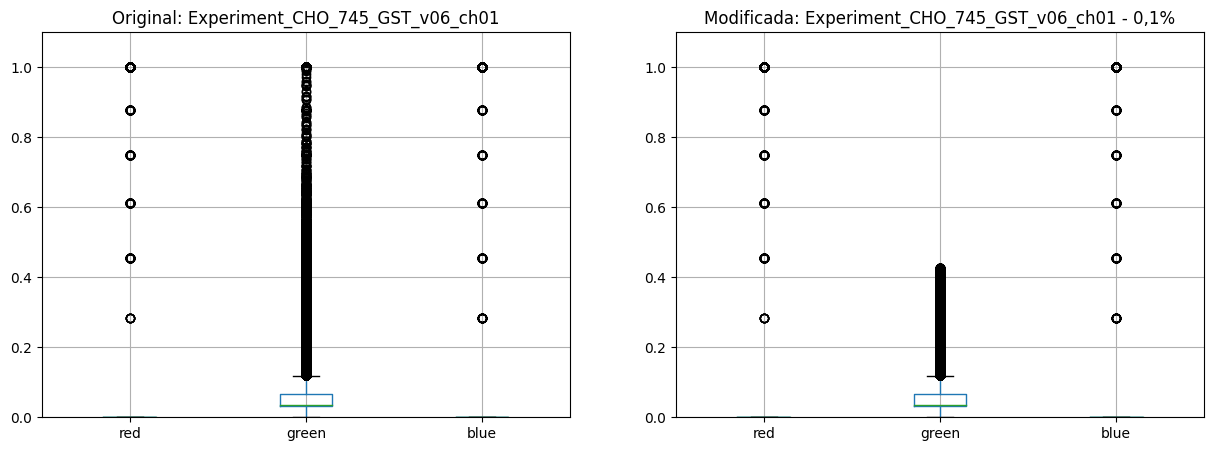

In [ ]:
plt.figure(figsize=(15,5))

plt.subplot(1, 2, 1)
plt.title(f"Original: {path[50:-4]}")
img_df_first.boxplot()
plt.ylim(0, maxplot())


plt.subplot(1, 2, 2)
plt.title(f"Modificada: {path[50:-4]} - 0,1%")
img_df_second.boxplot()
plt.ylim(0, maxplot())

# plt.plot( #função para plotar o gráfico
#     [plot_media, plot_media], #faixa que marca a média
#     c='red' #cor vermelha da faixa
# )
# plt.plot(#função para plotar o gráfico
#     [plot_mediana,plot_mediana],
#     c='green' #cor verde da faixa
# )


plt.show()

#Imagem original e pós nivelado os píxels:

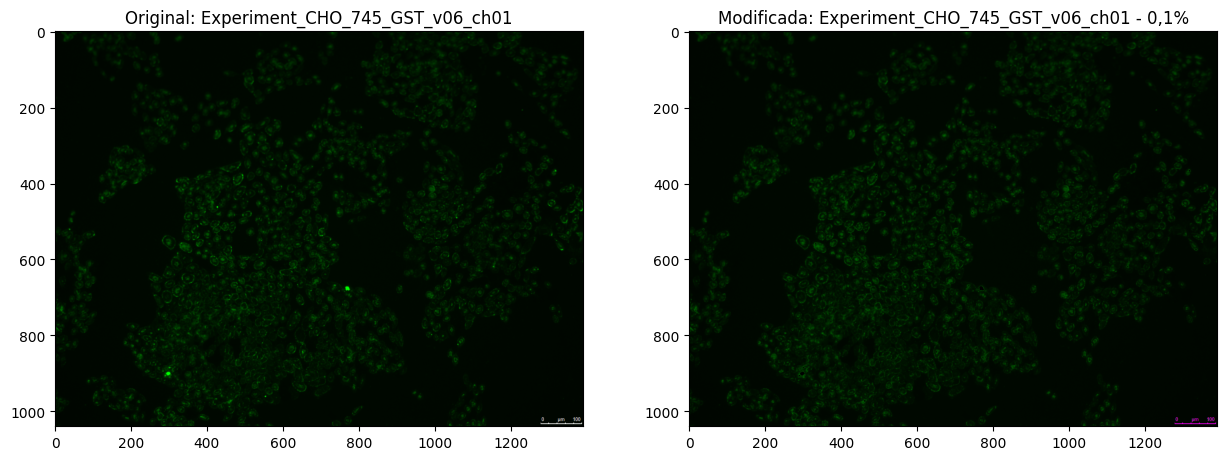

In [ ]:

plt.figure(figsize=(15,15))

plt.subplot(1, 2, 1)
plt.imshow(np.array(img_df_first).reshape(1040, 1392, 3))
plt.title(f"Original: {path[50:-4]}")

plt.subplot(1, 2, 2)
plt.imshow(np.array(img_df_second).reshape(1040, 1392, 3))
plt.title(f"Modificada: {path[50:-4]} - 0,1%")

# plt.subplot(1, 2, 3)
# plt.imshow(np.array(img_df_copy).reshape(1040, 1392, 3))
# plt.title(f"Modificada: {path[50:-4]}")
plt.show()

#Dataframe CHO 745 proteína GTS:

In [ ]:
img_df_gst = pd.DataFrame() #criando uma df
img_dict = {} #criando um dicionário

for path in lista_arquivos_fluo:  #laço para pasta o que tiver em lista de arquivos controle
  img = Image.open(path)              #abrinado a imagem que contem em path
  img_df_modif = img_df_second
  img_df_gst[path[61:-4]] = img_df_modif['green'] #renomeando a coluna com o final do nome do ar arquivo e sustituindo a coluna green

  img_dict[path[61:-4]] = img_df_modif

img_df_gst.head()

,CHO_745_GST_anti_v01_ch01,CHO_745_GST_anti_v02_ch01,CHO_745_GST_anti_v03_ch01,CHO_745_GST_anti_v04_ch01,CHO_745_GST_anti_v05_ch01,CHO_745_GST_anti_v06_ch01,CHO_745_GST_anti_v07_ch01,CHO_745_GST_anti_v08_ch01,CHO_745_GST_anti_v10_ch01,CHO_745_GST_anti_v9_ch01,...,CHO_745_GST_v02_ch01,CHO_745_GST_v03_ch01,CHO_745_GST_v04_ch01,CHO_745_GST_v05_ch01,CHO_745_GST_v06_ch01,CHO_745_GST_v07_ch01,CHO_745_GST_v08_ch01,CHO_745_GST_v09_ch01,CHO_745_GST_v10_ch01,CHO_745_GST_v11_ch01
0,0.031373,0.031373,0.031373,0.031373,0.031373,0.031373,0.031373,0.031373,0.031373,0.031373,...,0.031373,0.031373,0.031373,0.031373,0.031373,0.031373,0.031373,0.031373,0.031373,0.031373
1,0.027451,0.027451,0.027451,0.027451,0.027451,0.027451,0.027451,0.027451,0.027451,0.027451,...,0.027451,0.027451,0.027451,0.027451,0.027451,0.027451,0.027451,0.027451,0.027451,0.027451
2,0.023529,0.023529,0.023529,0.023529,0.023529,0.023529,0.023529,0.023529,0.023529,0.023529,...,0.023529,0.023529,0.023529,0.023529,0.023529,0.023529,0.023529,0.023529,0.023529,0.023529
3,0.031373,0.031373,0.031373,0.031373,0.031373,0.031373,0.031373,0.031373,0.031373,0.031373,...,0.031373,0.031373,0.031373,0.031373,0.031373,0.031373,0.031373,0.031373,0.031373,0.031373
4,0.031373,0.031373,0.031373,0.031373,0.031373,0.031373,0.031373,0.031373,0.031373,0.031373,...,0.031373,0.031373,0.031373,0.031373,0.031373,0.031373,0.031373,0.031373,0.031373,0.031373


In [ ]:
img_df_gst.describe()

,CHO_745_GST_anti_v01_ch01,CHO_745_GST_anti_v02_ch01,CHO_745_GST_anti_v03_ch01,CHO_745_GST_anti_v04_ch01,CHO_745_GST_anti_v05_ch01,CHO_745_GST_anti_v06_ch01,CHO_745_GST_anti_v07_ch01,CHO_745_GST_anti_v08_ch01,CHO_745_GST_anti_v10_ch01,CHO_745_GST_anti_v9_ch01,...,CHO_745_GST_v02_ch01,CHO_745_GST_v03_ch01,CHO_745_GST_v04_ch01,CHO_745_GST_v05_ch01,CHO_745_GST_v06_ch01,CHO_745_GST_v07_ch01,CHO_745_GST_v08_ch01,CHO_745_GST_v09_ch01,CHO_745_GST_v10_ch01,CHO_745_GST_v11_ch01
count,1.447680e+06,1.447680e+06,1.447680e+06,1.447680e+06,1.447680e+06,1.447680e+06,1.447680e+06,1.447680e+06,1.447680e+06,1.447680e+06,...,1.447680e+06,1.447680e+06,1.447680e+06,1.447680e+06,1.447680e+06,1.447680e+06,1.447680e+06,1.447680e+06,1.447680e+06,1.447680e+06
mean,5.620100e-02,5.620100e-02,5.620100e-02,5.620100e-02,5.620100e-02,5.620100e-02,5.620100e-02,5.620100e-02,5.620100e-02,5.620100e-02,...,5.620100e-02,5.620100e-02,5.620100e-02,5.620100e-02,5.620100e-02,5.620100e-02,5.620100e-02,5.620100e-02,5.620100e-02,5.620100e-02
std,4.239800e-02,4.239800e-02,4.239800e-02,4.239800e-02,4.239800e-02,4.239800e-02,4.239800e-02,4.239800e-02,4.239800e-02,4.239800e-02,...,4.239800e-02,4.239800e-02,4.239800e-02,4.239800e-02,4.239800e-02,4.239800e-02,4.239800e-02,4.239800e-02,4.239800e-02,4.239800e-02
min,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,...,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
25%,3.137255e-02,3.137255e-02,3.137255e-02,3.137255e-02,3.137255e-02,3.137255e-02,3.137255e-02,3.137255e-02,3.137255e-02,3.137255e-02,...,3.137255e-02,3.137255e-02,3.137255e-02,3.137255e-02,3.137255e-02,3.137255e-02,3.137255e-02,3.137255e-02,3.137255e-02,3.137255e-02
50%,3.529412e-02,3.529412e-02,3.529412e-02,3.529412e-02,3.529412e-02,3.529412e-02,3.529412e-02,3.529412e-02,3.529412e-02,3.529412e-02,...,3.529412e-02,3.529412e-02,3.529412e-02,3.529412e-02,3.529412e-02,3.529412e-02,3.529412e-02,3.529412e-02,3.529412e-02,3.529412e-02
75%,6.666667e-02,6.666667e-02,6.666667e-02,6.666667e-02,6.666667e-02,6.666667e-02,6.666667e-02,6.666667e-02,6.666667e-02,6.666667e-02,...,6.666667e-02,6.666667e-02,6.666667e-02,6.666667e-02,6.666667e-02,6.666667e-02,6.666667e-02,6.666667e-02,6.666667e-02,6.666667e-02
max,4.274510e-01,4.274510e-01,4.274510e-01,4.274510e-01,4.274510e-01,4.274510e-01,4.274510e-01,4.274510e-01,4.274510e-01,4.274510e-01,...,4.274510e-01,4.274510e-01,4.274510e-01,4.274510e-01,4.274510e-01,4.274510e-01,4.274510e-01,4.274510e-01,4.274510e-01,4.274510e-01


In [ ]:
#salvando a df:
data = timeProcess()[1]
#joblib.dump(pd.DataFrame(img_df_grupo), '/content/drive/MyDrive/teste/DataFrames pastas/DataFrames_retirada_porcentagens/dataframe-CHO745-GST-fluorescente-0,01%-'+data+'.gz')

#Chamando apenas as imagens dentro do VIR CHO-745:

In [ ]:
lista_arquivos_vir = [i for i in lista_arquivos if "/CHO-745/VIR/" in i]
lista_arquivos_fluo_vir = [i for i in lista_arquivos_vir if "ch01.tif" in i]

lista_arquivos_fluo_vir[:3]
len(lista_arquivos_fluo_vir)

31

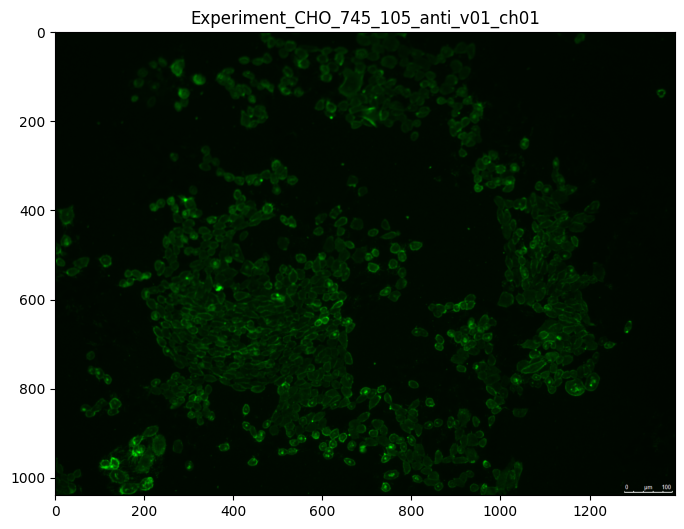

In [ ]:
path = lista_arquivos_fluo_vir[10] #chamando a primeira imagem
img = Image.open(path) #abrinado a primeira imagem

plt.figure(figsize=(8,8)) #tamanho da imagem
plt.imshow(img) #abrindo a imagem
plt.title(path[50:-4]) #título recortando o nome do título que corresponde o caminho da imagem[50:-4]
plt.show()

In [ ]:
img_df_vir = img_to_df(img=img) #chamando a função criada e como parâmetro está sendo passado a imagem organizada na pasta lá em cima.
img_df_vir.head()

,red,green,blue
0,0.0,0.031373,0.0
1,0.0,0.023529,0.0
2,0.0,0.031373,0.0
3,0.0,0.027451,0.0
4,0.0,0.027451,0.0


In [ ]:
img_df_green = img_df_vir['green'].copy() #copiando apenas a coluna verde da df original
freq = img_df_green.value_counts(normalize=True).to_frame().reset_index().sort_values('green', ascending=False)
#Acima: foi calculado a frequencia dos pixels na camada verde, convertido essa serie em DF, resetado index e organizado do maior para menor valor de pixel
freq

,green,proportion
81,1.000000,2.728504e-04
246,0.992157,6.907604e-07
229,0.988235,2.072281e-06
243,0.984314,1.381521e-06
244,0.980392,1.381521e-06
...,...,...
1,0.031373,1.804273e-01
2,0.027451,1.233843e-01
5,0.023529,2.194684e-02
77,0.019608,3.046253e-04


In [ ]:
soma = 0 #igualando a variavel a 0
for n in range(len(freq)): #iteração para percorrer na df e somar os valores da coluna 1
  soma += freq.iloc[n,1]
  if soma >= 0.001: #5% dos dados
    print(soma)
    break
print(freq.iloc[n,:])

0.001011963969938108
green         0.584314
proportion    0.000019
Name: 149, dtype: float64


In [ ]:
img_df_vir_cho = img_df_vir.copy()

In [ ]:
novo_valor = 0.0  # converter os valores em zero
img_df_vir_cho.loc[img_df_vir_cho['green'] >= 0.584314, 'green'] = novo_valor
img_df_vir_cho

,red,green,blue
0,0.0,0.031373,0.0
1,0.0,0.023529,0.0
2,0.0,0.031373,0.0
3,0.0,0.027451,0.0
4,0.0,0.027451,0.0
...,...,...,...
1447675,0.0,0.035294,0.0
1447676,0.0,0.031373,0.0
1447677,0.0,0.027451,0.0
1447678,0.0,0.027451,0.0


(0.0, 1.1)

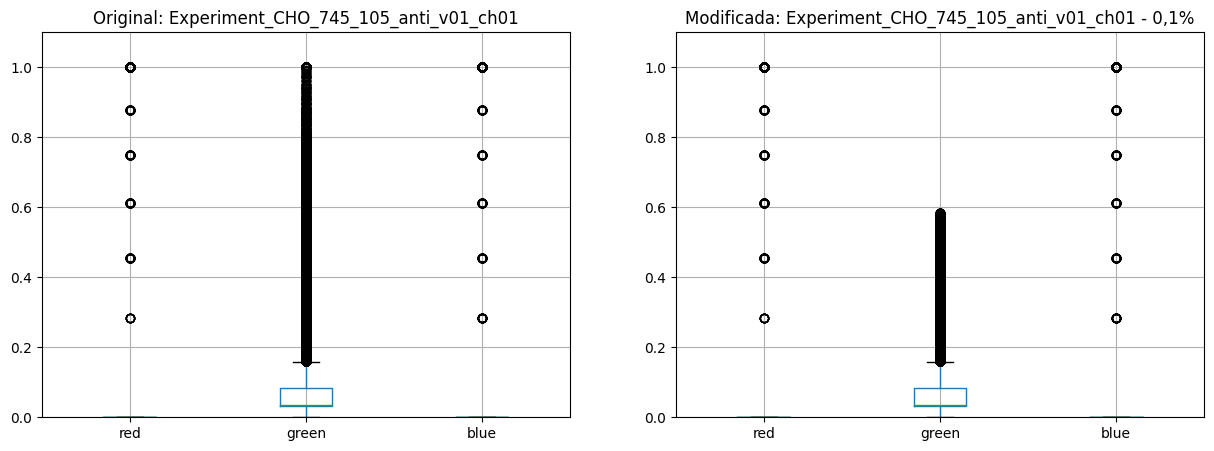

In [ ]:
plt.figure(figsize=(15,5))

plt.subplot(1, 2, 1)
plt.title(f"Original: {path[50:-4]}")
img_df_vir.boxplot()
plt.ylim(0, maxplot())


plt.subplot(1, 2, 2)
plt.title(f"Modificada: {path[50:-4]} - 0,1%")
img_df_vir_cho.boxplot()
plt.ylim(0, maxplot())

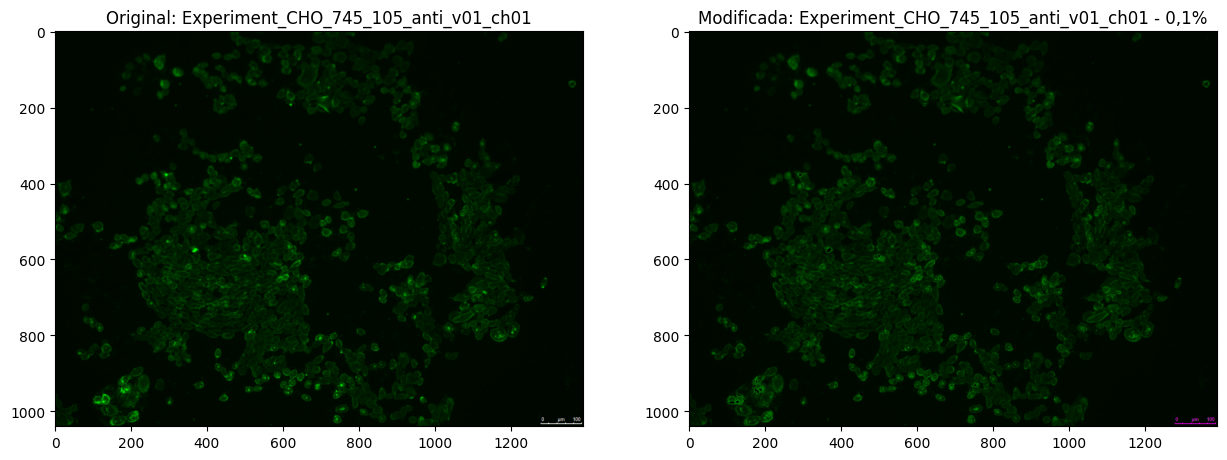

In [ ]:
plt.figure(figsize=(15,15))

plt.subplot(1, 2, 1)
plt.imshow(np.array(img_df_vir).reshape(1040, 1392, 3))
plt.title(f"Original: {path[50:-4]}")

plt.subplot(1, 2, 2)
plt.imshow(np.array(img_df_vir_cho).reshape(1040, 1392, 3))
plt.title(f"Modificada: {path[50:-4]} - 0,1%")

# plt.subplot(1, 2, 3)
# plt.imshow(np.array(img_df_copy).reshape(1040, 1392, 3))
# plt.title(f"Modificada: {path[50:-4]}")
plt.show()

In [ ]:
img_df_grupo_vir= pd.DataFrame() #criando uma df
img_dict = {} #criando um dicionário

for path in lista_arquivos_fluo_vir:  #laço para pasta o que tiver em lista de arquivos controle
  img = Image.open(path)              #abrinado a imagem que contem em path
  img_df_modif = img_df_vir_cho
  img_df_grupo_vir[path[61:-4]] = img_df_modif['green'] #renomeando a coluna com o final do nome do ar arquivo e sustituindo a coluna green

  img_dict[path[61:-4]] = img_df_modif

img_df_grupo_vir.head()

,CHO_745_096_anti_v01_ch01,CHO_745_096_anti_v02_ch01,CHO_745_096_anti_v03_ch01,CHO_745_096_anti_v04_ch01,CHO_745_096_anti_v05_ch01,CHO_745_096_v01_ch01,CHO_745_096_v02_ch01,CHO_745_096_v03_ch01,CHO_745_096_v04_ch01,CHO_745_096_v05_ch01,...,CHO_745_105_v02_ch01,CHO_745_105_v03_ch01,CHO_745_105_v04_ch01,CHO_745_105_v05_ch01,CHO_745_105_v06_ch01,CHO_745_105_v07_ch01,CHO_745_105_v08_ch01,CHO_745_105_v09_ch01,CHO_745_105_v10_ch01,CHO_745_105_v11_ch01
0,0.031373,0.031373,0.031373,0.031373,0.031373,0.031373,0.031373,0.031373,0.031373,0.031373,...,0.031373,0.031373,0.031373,0.031373,0.031373,0.031373,0.031373,0.031373,0.031373,0.031373
1,0.023529,0.023529,0.023529,0.023529,0.023529,0.023529,0.023529,0.023529,0.023529,0.023529,...,0.023529,0.023529,0.023529,0.023529,0.023529,0.023529,0.023529,0.023529,0.023529,0.023529
2,0.031373,0.031373,0.031373,0.031373,0.031373,0.031373,0.031373,0.031373,0.031373,0.031373,...,0.031373,0.031373,0.031373,0.031373,0.031373,0.031373,0.031373,0.031373,0.031373,0.031373
3,0.027451,0.027451,0.027451,0.027451,0.027451,0.027451,0.027451,0.027451,0.027451,0.027451,...,0.027451,0.027451,0.027451,0.027451,0.027451,0.027451,0.027451,0.027451,0.027451,0.027451
4,0.027451,0.027451,0.027451,0.027451,0.027451,0.027451,0.027451,0.027451,0.027451,0.027451,...,0.027451,0.027451,0.027451,0.027451,0.027451,0.027451,0.027451,0.027451,0.027451,0.027451


In [ ]:
img_df_grupo_vir.describe()

,CHO_745_096_anti_v01_ch01,CHO_745_096_anti_v02_ch01,CHO_745_096_anti_v03_ch01,CHO_745_096_anti_v04_ch01,CHO_745_096_anti_v05_ch01,CHO_745_096_v01_ch01,CHO_745_096_v02_ch01,CHO_745_096_v03_ch01,CHO_745_096_v04_ch01,CHO_745_096_v05_ch01,...,CHO_745_105_v02_ch01,CHO_745_105_v03_ch01,CHO_745_105_v04_ch01,CHO_745_105_v05_ch01,CHO_745_105_v06_ch01,CHO_745_105_v07_ch01,CHO_745_105_v08_ch01,CHO_745_105_v09_ch01,CHO_745_105_v10_ch01,CHO_745_105_v11_ch01
count,1.447680e+06,1.447680e+06,1.447680e+06,1.447680e+06,1.447680e+06,1.447680e+06,1.447680e+06,1.447680e+06,1.447680e+06,1.447680e+06,...,1.447680e+06,1.447680e+06,1.447680e+06,1.447680e+06,1.447680e+06,1.447680e+06,1.447680e+06,1.447680e+06,1.447680e+06,1.447680e+06
mean,6.425395e-02,6.425395e-02,6.425395e-02,6.425395e-02,6.425395e-02,6.425395e-02,6.425395e-02,6.425395e-02,6.425395e-02,6.425395e-02,...,6.425395e-02,6.425395e-02,6.425395e-02,6.425395e-02,6.425395e-02,6.425395e-02,6.425395e-02,6.425395e-02,6.425395e-02,6.425395e-02
std,5.799141e-02,5.799141e-02,5.799141e-02,5.799141e-02,5.799141e-02,5.799141e-02,5.799141e-02,5.799141e-02,5.799141e-02,5.799141e-02,...,5.799141e-02,5.799141e-02,5.799141e-02,5.799141e-02,5.799141e-02,5.799141e-02,5.799141e-02,5.799141e-02,5.799141e-02,5.799141e-02
min,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,...,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
25%,3.137255e-02,3.137255e-02,3.137255e-02,3.137255e-02,3.137255e-02,3.137255e-02,3.137255e-02,3.137255e-02,3.137255e-02,3.137255e-02,...,3.137255e-02,3.137255e-02,3.137255e-02,3.137255e-02,3.137255e-02,3.137255e-02,3.137255e-02,3.137255e-02,3.137255e-02,3.137255e-02
50%,3.529412e-02,3.529412e-02,3.529412e-02,3.529412e-02,3.529412e-02,3.529412e-02,3.529412e-02,3.529412e-02,3.529412e-02,3.529412e-02,...,3.529412e-02,3.529412e-02,3.529412e-02,3.529412e-02,3.529412e-02,3.529412e-02,3.529412e-02,3.529412e-02,3.529412e-02,3.529412e-02
75%,8.235294e-02,8.235294e-02,8.235294e-02,8.235294e-02,8.235294e-02,8.235294e-02,8.235294e-02,8.235294e-02,8.235294e-02,8.235294e-02,...,8.235294e-02,8.235294e-02,8.235294e-02,8.235294e-02,8.235294e-02,8.235294e-02,8.235294e-02,8.235294e-02,8.235294e-02,8.235294e-02
max,5.843137e-01,5.843137e-01,5.843137e-01,5.843137e-01,5.843137e-01,5.843137e-01,5.843137e-01,5.843137e-01,5.843137e-01,5.843137e-01,...,5.843137e-01,5.843137e-01,5.843137e-01,5.843137e-01,5.843137e-01,5.843137e-01,5.843137e-01,5.843137e-01,5.843137e-01,5.843137e-01


In [ ]:
#joblib.dump(pd.DataFrame(img_df_grupo), '/content/drive/MyDrive/teste/DataFrames pastas/DataFrames_retirada_porcentagens/dataframe-CHO745-VIR-fluorescente-0,01%-'+data+'.gz')

#Chamando apenas as imagens dentro do Controle CHO-745:

In [ ]:
lista_arquivos_vir_ctrl = [i for i in lista_arquivos if "Experiment_CHO_745_cntl" in i]
lista_arquivos_fluo_vir_ctrl = [i for i in lista_arquivos_vir_ctrl if "ch01.tif" in i]

#lista_arquivos_fluo_vir_ctrl[:3]
len(lista_arquivos_fluo_vir_ctrl)

27

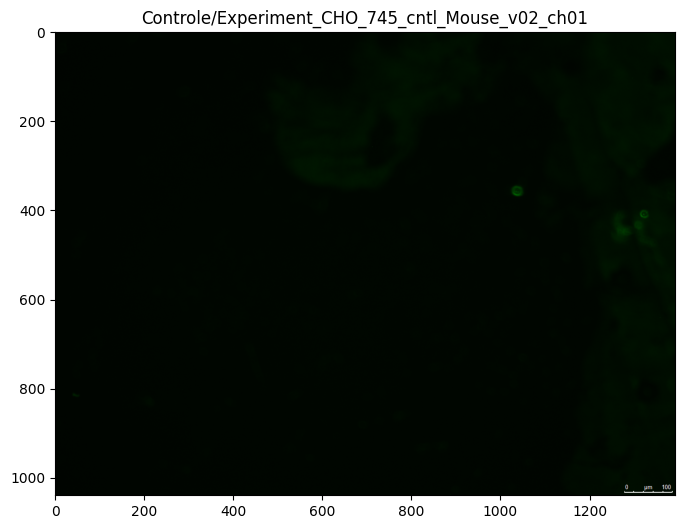

In [ ]:
path = lista_arquivos_fluo_vir_ctrl[16] #chamando a primeira imagem
img = Image.open(path) #abrinado a primeira imagem

plt.figure(figsize=(8,8)) #tamanho da imagem
plt.imshow(img) #abrindo a imagem
plt.title(path[46:-4]) #título recortando o nome do título que corresponde o caminho da imagem[50:-4]
plt.show()

In [ ]:
img_df = img_to_df(img=img) #chamando a função criada e como parâmetro está sendo passado a imagem organizada na pasta lá em cima.
img_df.head()

,red,green,blue
0,0.0,0.019608,0.0
1,0.0,0.019608,0.0
2,0.0,0.019608,0.0
3,0.0,0.019608,0.0
4,0.0,0.019608,0.0


In [ ]:
img_df_green = img_df['green'].copy() #copiando apenas a coluna verde da df original
freq = img_df_green.value_counts(normalize=True).to_frame().reset_index().sort_values('green', ascending=False)
#Acima: foi calculado a frequencia dos pixels na camada verde, convertido essa serie em DF, resetado index e organizado do maior para menor valor de pixel
freq

,green,proportion
21,1.000000,0.000227
58,0.878431,0.000013
53,0.749020,0.000018
67,0.611765,0.000005
60,0.454902,0.000012
...,...,...
0,0.023529,0.328466
2,0.019608,0.103519
15,0.015686,0.003635
78,0.011765,0.000003


In [ ]:
soma = 0 #igualando a variavel a 0
for n in range(len(freq)): #iteração para percorrer na df e somar os valores da coluna 1
  soma += freq.iloc[n,1]
  if soma >= 0.001: #5% dos dados
    print(soma)
    break
print(freq.iloc[n,:])

0.001012654730327144
green         0.164706
proportion    0.000063
Name: 37, dtype: float64


In [ ]:
img_df_cntrl = img_df.copy()

In [ ]:
novo_valor = 0.0  # converter os valores em zero
img_df_cntrl.loc[img_df_cntrl['green'] >= 0.164706, 'green'] = novo_valor
img_df_cntrl

,red,green,blue
0,0.0,0.019608,0.0
1,0.0,0.019608,0.0
2,0.0,0.019608,0.0
3,0.0,0.019608,0.0
4,0.0,0.019608,0.0
...,...,...,...
1447675,0.0,0.043137,0.0
1447676,0.0,0.039216,0.0
1447677,0.0,0.043137,0.0
1447678,0.0,0.043137,0.0


(0.0, 1.1)

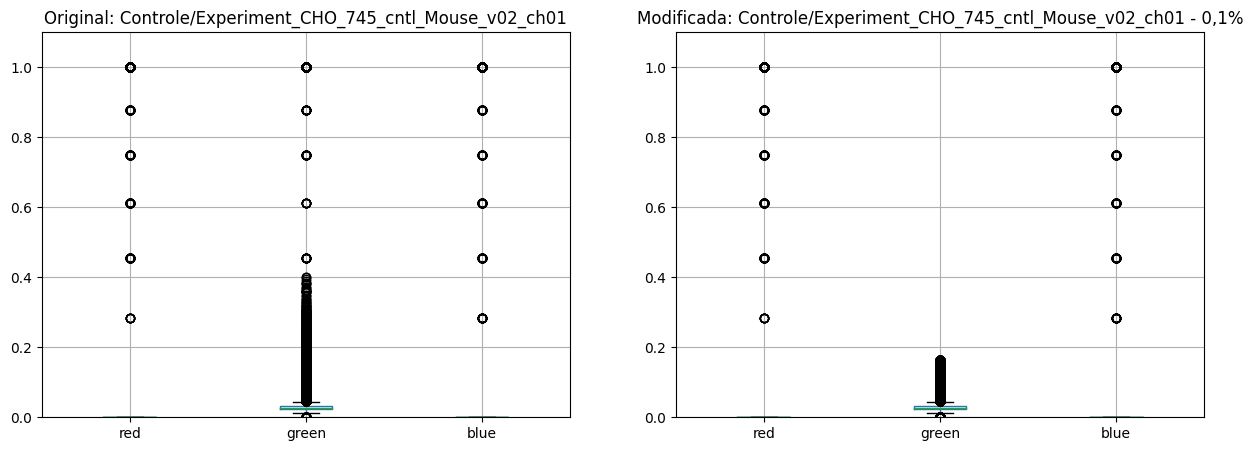

In [ ]:
plt.figure(figsize=(15,5))

plt.subplot(1, 2, 1)
plt.title(f"Original: {path[46:-4]}")
img_df.boxplot()
plt.ylim(0, maxplot())


plt.subplot(1, 2, 2)
plt.title(f"Modificada: {path[46:-4]} - 0,1%")
img_df_cntrl.boxplot()
plt.ylim(0, maxplot())

Text(0.5, 1.0, 'Modificada: Controle/Experiment_CHO_745_cntl_Mouse_v02_ch01 - 0,1%')

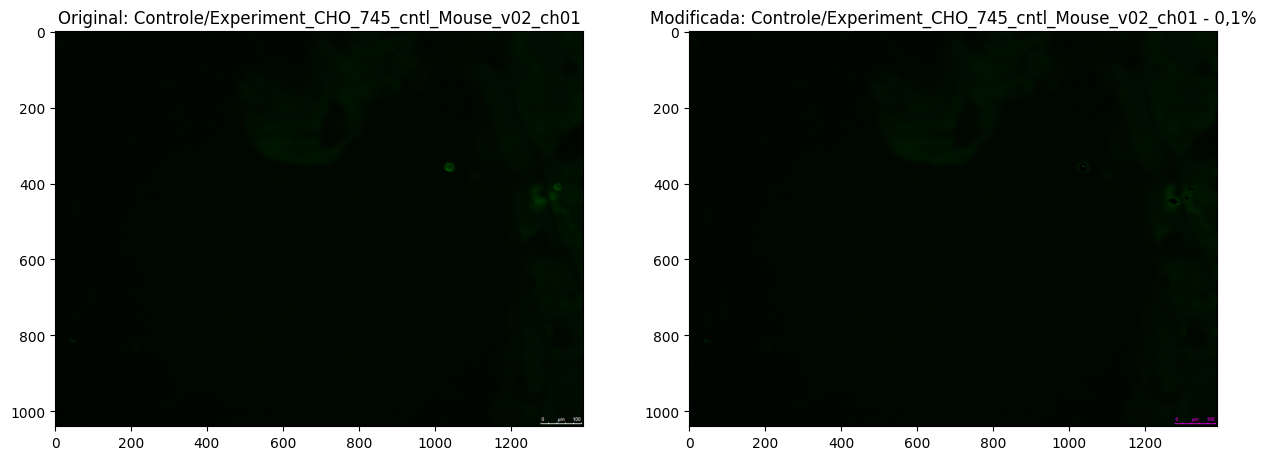

In [ ]:
plt.figure(figsize=(15,15))

plt.subplot(1, 2, 1)
plt.imshow(np.array(img_df).reshape(1040, 1392, 3))
plt.title(f"Original: {path[46:-4]}")

plt.subplot(1, 2, 2)
plt.imshow(np.array(img_df_cntrl).reshape(1040, 1392, 3))
plt.title(f"Modificada: {path[46:-4]} - 0,1%")



In [ ]:
img_df_grupo = pd.DataFrame() #criando uma df
img_dict = {} #criando um dicionário

for path in lista_arquivos_fluo_vir_ctrl:  #laço para pasta o que tiver em lista de arquivos controle
  img = Image.open(path)              #abrinado a imagem que contem em path
  img_df_modif = img_df_cntrl
  img_df_grupo[path[61:-4]] = img_df_modif['green'] #renomeando a coluna com o final do nome do ar arquivo e sustituindo a coluna green

  img_dict[path[61:-4]] = img_df_modif

img_df_grupo.head()

,ment_CHO_745_cntl_CHO_v01_ch01,ment_CHO_745_cntl_CHO_v02_ch01,ment_CHO_745_cntl_CHO_v03_ch01,ment_CHO_745_cntl_CHO_v04_ch01,ment_CHO_745_cntl_CHO_v05_ch01,ment_CHO_745_cntl_ICAM_v01_ch01,ment_CHO_745_cntl_ICAM_v02_ch01,ment_CHO_745_cntl_ICAM_v03_ch01,ment_CHO_745_cntl_ICAM_v04_ch01,ment_CHO_745_cntl_ICAM_v05_ch01,...,ment_CHO_745_cntl_Mouse_v03_ch01,ment_CHO_745_cntl_Mouse_v04_ch01,ment_CHO_745_cntl_Mouse_v05_ch01,ment_CHO_745_cntl_Mouse_v06_ch01,ment_CHO_745_cntl_Rabbit_v01_ch01,ment_CHO_745_cntl_Rabbit_v02_ch01,ment_CHO_745_cntl_Rabbit_v03_ch01,ment_CHO_745_cntl_Rabbit_v04_ch01,ment_CHO_745_cntl_Rabbit_v05_ch01,ment_CHO_745_cntl_Rabbit_v06_ch01
0,0.019608,0.019608,0.019608,0.019608,0.019608,0.019608,0.019608,0.019608,0.019608,0.019608,...,0.019608,0.019608,0.019608,0.019608,0.019608,0.019608,0.019608,0.019608,0.019608,0.019608
1,0.019608,0.019608,0.019608,0.019608,0.019608,0.019608,0.019608,0.019608,0.019608,0.019608,...,0.019608,0.019608,0.019608,0.019608,0.019608,0.019608,0.019608,0.019608,0.019608,0.019608
2,0.019608,0.019608,0.019608,0.019608,0.019608,0.019608,0.019608,0.019608,0.019608,0.019608,...,0.019608,0.019608,0.019608,0.019608,0.019608,0.019608,0.019608,0.019608,0.019608,0.019608
3,0.019608,0.019608,0.019608,0.019608,0.019608,0.019608,0.019608,0.019608,0.019608,0.019608,...,0.019608,0.019608,0.019608,0.019608,0.019608,0.019608,0.019608,0.019608,0.019608,0.019608
4,0.019608,0.019608,0.019608,0.019608,0.019608,0.019608,0.019608,0.019608,0.019608,0.019608,...,0.019608,0.019608,0.019608,0.019608,0.019608,0.019608,0.019608,0.019608,0.019608,0.019608


In [ ]:
img_df_grupo.describe()

,ment_CHO_745_cntl_CHO_v01_ch01,ment_CHO_745_cntl_CHO_v02_ch01,ment_CHO_745_cntl_CHO_v03_ch01,ment_CHO_745_cntl_CHO_v04_ch01,ment_CHO_745_cntl_CHO_v05_ch01,ment_CHO_745_cntl_ICAM_v01_ch01,ment_CHO_745_cntl_ICAM_v02_ch01,ment_CHO_745_cntl_ICAM_v03_ch01,ment_CHO_745_cntl_ICAM_v04_ch01,ment_CHO_745_cntl_ICAM_v05_ch01,...,ment_CHO_745_cntl_Mouse_v03_ch01,ment_CHO_745_cntl_Mouse_v04_ch01,ment_CHO_745_cntl_Mouse_v05_ch01,ment_CHO_745_cntl_Mouse_v06_ch01,ment_CHO_745_cntl_Rabbit_v01_ch01,ment_CHO_745_cntl_Rabbit_v02_ch01,ment_CHO_745_cntl_Rabbit_v03_ch01,ment_CHO_745_cntl_Rabbit_v04_ch01,ment_CHO_745_cntl_Rabbit_v05_ch01,ment_CHO_745_cntl_Rabbit_v06_ch01
count,1.447680e+06,1.447680e+06,1.447680e+06,1.447680e+06,1.447680e+06,1.447680e+06,1.447680e+06,1.447680e+06,1.447680e+06,1.447680e+06,...,1.447680e+06,1.447680e+06,1.447680e+06,1.447680e+06,1.447680e+06,1.447680e+06,1.447680e+06,1.447680e+06,1.447680e+06,1.447680e+06
mean,3.158835e-02,3.158835e-02,3.158835e-02,3.158835e-02,3.158835e-02,3.158835e-02,3.158835e-02,3.158835e-02,3.158835e-02,3.158835e-02,...,3.158835e-02,3.158835e-02,3.158835e-02,3.158835e-02,3.158835e-02,3.158835e-02,3.158835e-02,3.158835e-02,3.158835e-02,3.158835e-02
std,1.376679e-02,1.376679e-02,1.376679e-02,1.376679e-02,1.376679e-02,1.376679e-02,1.376679e-02,1.376679e-02,1.376679e-02,1.376679e-02,...,1.376679e-02,1.376679e-02,1.376679e-02,1.376679e-02,1.376679e-02,1.376679e-02,1.376679e-02,1.376679e-02,1.376679e-02,1.376679e-02
min,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,...,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
25%,2.352941e-02,2.352941e-02,2.352941e-02,2.352941e-02,2.352941e-02,2.352941e-02,2.352941e-02,2.352941e-02,2.352941e-02,2.352941e-02,...,2.352941e-02,2.352941e-02,2.352941e-02,2.352941e-02,2.352941e-02,2.352941e-02,2.352941e-02,2.352941e-02,2.352941e-02,2.352941e-02
50%,2.745098e-02,2.745098e-02,2.745098e-02,2.745098e-02,2.745098e-02,2.745098e-02,2.745098e-02,2.745098e-02,2.745098e-02,2.745098e-02,...,2.745098e-02,2.745098e-02,2.745098e-02,2.745098e-02,2.745098e-02,2.745098e-02,2.745098e-02,2.745098e-02,2.745098e-02,2.745098e-02
75%,3.137255e-02,3.137255e-02,3.137255e-02,3.137255e-02,3.137255e-02,3.137255e-02,3.137255e-02,3.137255e-02,3.137255e-02,3.137255e-02,...,3.137255e-02,3.137255e-02,3.137255e-02,3.137255e-02,3.137255e-02,3.137255e-02,3.137255e-02,3.137255e-02,3.137255e-02,3.137255e-02
max,1.647059e-01,1.647059e-01,1.647059e-01,1.647059e-01,1.647059e-01,1.647059e-01,1.647059e-01,1.647059e-01,1.647059e-01,1.647059e-01,...,1.647059e-01,1.647059e-01,1.647059e-01,1.647059e-01,1.647059e-01,1.647059e-01,1.647059e-01,1.647059e-01,1.647059e-01,1.647059e-01


#Chamando apenas as imagens dentro do GST ICAM:

In [ ]:
lista_arquivos_gst_icam = [i for i in lista_arquivos if "/CHO-ICAM/GTS/" in i]
lista_arquivos_gst_icam_fluo = [i for i in lista_arquivos_gst_icam if "ch01.tif" in i]

print(len(lista_arquivos_gst_icam_fluo))
lista_arquivos_gst_icam_fluo[0:3]

40


['./drive/MyDrive/teste/imagem_conjunto/CHO-ICAM/GTS/Experiment_CHO_ICAM_GST_10ug_11_ch01.tif',
 './drive/MyDrive/teste/imagem_conjunto/CHO-ICAM/GTS/Experiment_CHO_ICAM_GST_10ug_12_ch01.tif',
 './drive/MyDrive/teste/imagem_conjunto/CHO-ICAM/GTS/Experiment_CHO_ICAM_GST_10ug_13_ch01.tif']

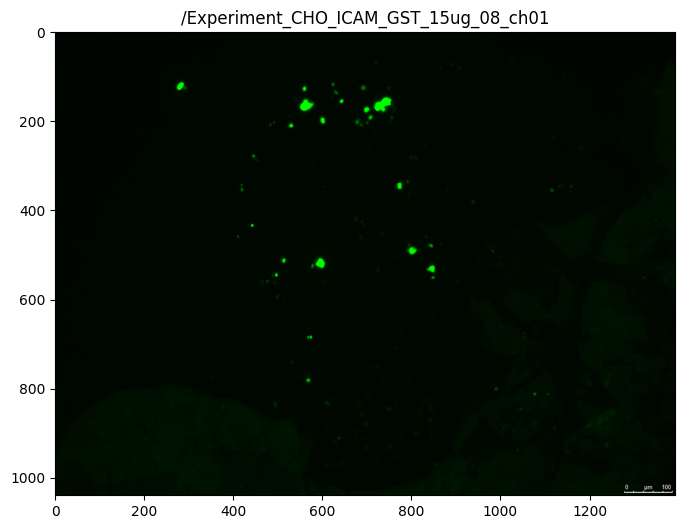

In [ ]:
path = lista_arquivos_gst_icam_fluo[12] #chamando a primeira imagem
img = Image.open(path) #abrinado a primeira imagem

plt.figure(figsize=(8,8)) #tamanho da imagem
plt.imshow(img) #abrindo a imagem
plt.title(path[50:-4]) #título recortando o nome do título que corresponde o caminho da imagem[50:-4]
plt.show()

In [ ]:
img_df = img_to_df(img=img) #chamando a função criada e como parâmetro está sendo passado a imagem organizada na pasta lá em cima.
img_df.head()

,red,green,blue
0,0.0,0.019608,0.0
1,0.0,0.019608,0.0
2,0.0,0.019608,0.0
3,0.0,0.019608,0.0
4,0.0,0.019608,0.0


In [ ]:
img_df_green = img_df['green'].copy() #copiando apenas a coluna verde da df original
freq = img_df_green.value_counts(normalize=True).to_frame().reset_index().sort_values('green', ascending=False)
#Acima: foi calculado a frequencia dos pixels na camada verde, convertido essa serie em DF, resetado index e organizado do maior para menor valor de pixel
freq

,green,proportion
17,1.000000,0.001188
52,0.996078,0.000039
49,0.992157,0.000042
57,0.988235,0.000037
54,0.984314,0.000038
...,...,...
0,0.027451,0.328324
1,0.023529,0.245406
6,0.019608,0.030311
48,0.015686,0.000043


In [ ]:
soma = 0 #igualando a variavel a 0
for n in range(len(freq)): #iteração para percorrer na df e somar os valores da coluna 1
  soma += freq.iloc[n,1]
  if soma >= 0.001: #5% dos dados
    print(soma)
    break
print(freq.iloc[n,:])

0.001188107869142352
green         1.000000
proportion    0.001188
Name: 17, dtype: float64


In [ ]:
img_df_gst_icam = img_df.copy()

In [ ]:
novo_valor = 0.0  # converter os valores em zero
img_df_gst_icam.loc[img_df_gst_icam['green'] >= 0.368627, 'green'] = novo_valor
img_df_gst_icam

,red,green,blue
0,0.0,0.019608,0.0
1,0.0,0.019608,0.0
2,0.0,0.019608,0.0
3,0.0,0.019608,0.0
4,0.0,0.019608,0.0
...,...,...,...
1447675,0.0,0.027451,0.0
1447676,0.0,0.027451,0.0
1447677,0.0,0.027451,0.0
1447678,0.0,0.027451,0.0


(0.0, 1.1)

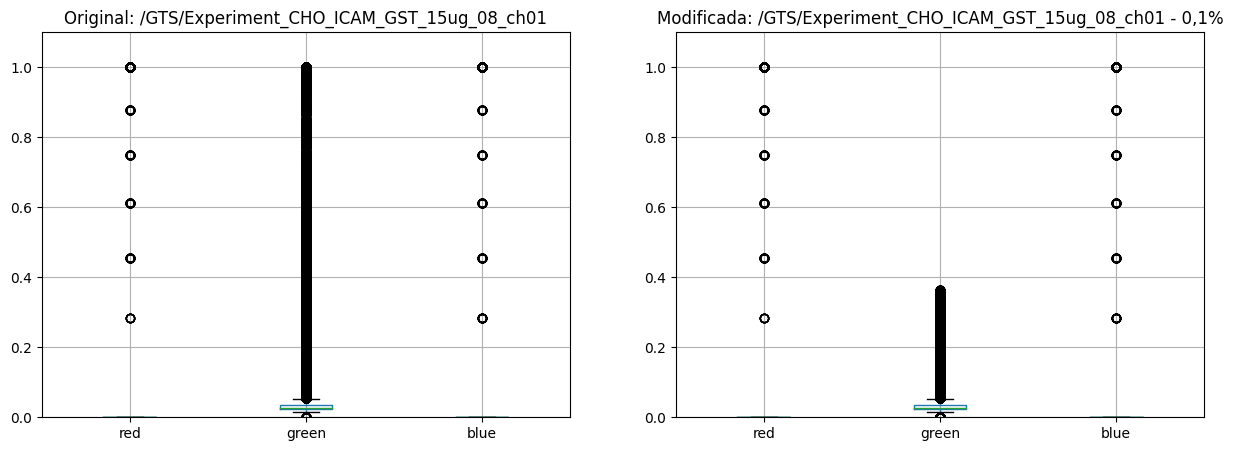

In [ ]:
plt.figure(figsize=(15,5))

plt.subplot(1, 2, 1)
plt.title(f"Original: {path[46:-4]}")
img_df.boxplot()
plt.ylim(0, maxplot())


plt.subplot(1, 2, 2)
plt.title(f"Modificada: {path[46:-4]} - 0,1%")
img_df_gst_icam.boxplot()
plt.ylim(0, maxplot())

Text(0.5, 1.0, 'Modificada: /GTS/Experiment_CHO_ICAM_GST_15ug_08_ch01 - 0,1%')

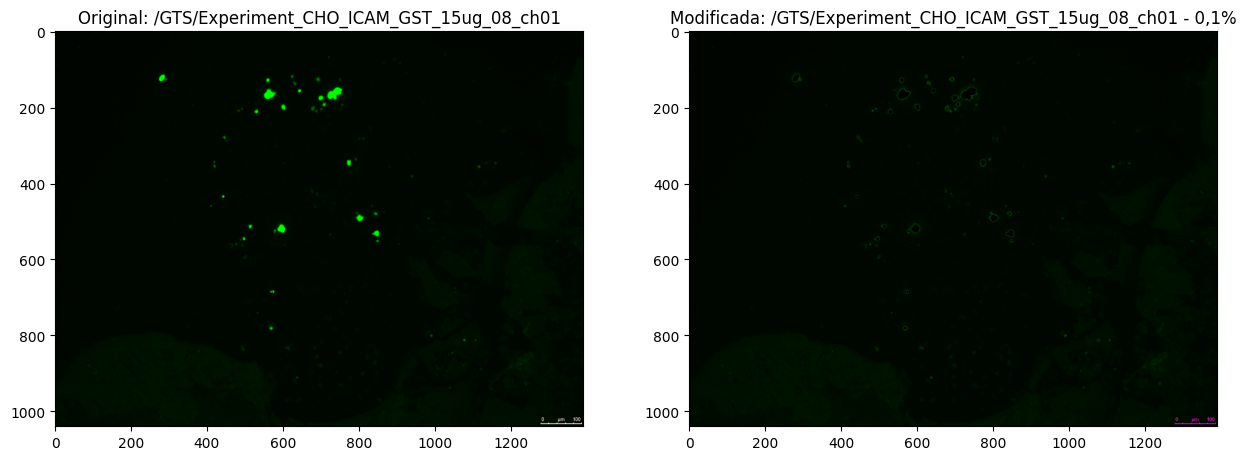

In [ ]:
plt.figure(figsize=(15,15))

plt.subplot(1, 2, 1)
plt.imshow(np.array(img_df).reshape(1040, 1392, 3))
plt.title(f"Original: {path[46:-4]}")

plt.subplot(1, 2, 2)
plt.imshow(np.array(img_df_gst_icam).reshape(1040, 1392, 3))
plt.title(f"Modificada: {path[46:-4]} - 0,1%")

In [ ]:
img_df_grupo = pd.DataFrame() #criando uma df
img_dict = {} #criando um dicionário

for path in lista_arquivos_gst_icam_fluo:  #laço para pasta o que tiver em lista de arquivos controle
  img = Image.open(path)              #abrinado a imagem que contem em path
  img_df_modif = img_df_gst_icam
  img_df_grupo[path[61:-4]] = img_df_modif['green'] #renomeando a coluna com o final do nome do ar arquivo e sustituindo a coluna green

  img_dict[path[61:-4]] = img_df_modif

img_df_grupo.head()

,_CHO_ICAM_GST_10ug_11_ch01,_CHO_ICAM_GST_10ug_12_ch01,_CHO_ICAM_GST_10ug_13_ch01,_CHO_ICAM_GST_10ug_14_ch01,_CHO_ICAM_GST_10ug_15_ch01,_CHO_ICAM_GST_10ug_16_ch01,_CHO_ICAM_GST_10ug_17_ch01,_CHO_ICAM_GST_10ug_18_ch01,_CHO_ICAM_GST_10ug_19_ch01,_CHO_ICAM_GST_10ug_20_ch01,...,_CHO_ICAM_GST_5ug_11_ch01,_CHO_ICAM_GST_5ug_12_ch01,_CHO_ICAM_GST_5ug_13_ch01,_CHO_ICAM_GST_5ug_14_ch01,_CHO_ICAM_GST_5ug_15_ch01,_CHO_ICAM_GST_5ug_16_ch01,_CHO_ICAM_GST_5ug_17_ch01,_CHO_ICAM_GST_5ug_18_ch01,_CHO_ICAM_GST_5ug_19_ch01,_CHO_ICAM_GST_5ug_20_ch01
0,0.019608,0.019608,0.019608,0.019608,0.019608,0.019608,0.019608,0.019608,0.019608,0.019608,...,0.019608,0.019608,0.019608,0.019608,0.019608,0.019608,0.019608,0.019608,0.019608,0.019608
1,0.019608,0.019608,0.019608,0.019608,0.019608,0.019608,0.019608,0.019608,0.019608,0.019608,...,0.019608,0.019608,0.019608,0.019608,0.019608,0.019608,0.019608,0.019608,0.019608,0.019608
2,0.019608,0.019608,0.019608,0.019608,0.019608,0.019608,0.019608,0.019608,0.019608,0.019608,...,0.019608,0.019608,0.019608,0.019608,0.019608,0.019608,0.019608,0.019608,0.019608,0.019608
3,0.019608,0.019608,0.019608,0.019608,0.019608,0.019608,0.019608,0.019608,0.019608,0.019608,...,0.019608,0.019608,0.019608,0.019608,0.019608,0.019608,0.019608,0.019608,0.019608,0.019608
4,0.019608,0.019608,0.019608,0.019608,0.019608,0.019608,0.019608,0.019608,0.019608,0.019608,...,0.019608,0.019608,0.019608,0.019608,0.019608,0.019608,0.019608,0.019608,0.019608,0.019608


In [ ]:
img_df_grupo.describe()

,_CHO_ICAM_GST_10ug_11_ch01,_CHO_ICAM_GST_10ug_12_ch01,_CHO_ICAM_GST_10ug_13_ch01,_CHO_ICAM_GST_10ug_14_ch01,_CHO_ICAM_GST_10ug_15_ch01,_CHO_ICAM_GST_10ug_16_ch01,_CHO_ICAM_GST_10ug_17_ch01,_CHO_ICAM_GST_10ug_18_ch01,_CHO_ICAM_GST_10ug_19_ch01,_CHO_ICAM_GST_10ug_20_ch01,...,_CHO_ICAM_GST_5ug_11_ch01,_CHO_ICAM_GST_5ug_12_ch01,_CHO_ICAM_GST_5ug_13_ch01,_CHO_ICAM_GST_5ug_14_ch01,_CHO_ICAM_GST_5ug_15_ch01,_CHO_ICAM_GST_5ug_16_ch01,_CHO_ICAM_GST_5ug_17_ch01,_CHO_ICAM_GST_5ug_18_ch01,_CHO_ICAM_GST_5ug_19_ch01,_CHO_ICAM_GST_5ug_20_ch01
count,1.447680e+06,1.447680e+06,1.447680e+06,1.447680e+06,1.447680e+06,1.447680e+06,1.447680e+06,1.447680e+06,1.447680e+06,1.447680e+06,...,1.447680e+06,1.447680e+06,1.447680e+06,1.447680e+06,1.447680e+06,1.447680e+06,1.447680e+06,1.447680e+06,1.447680e+06,1.447680e+06
mean,3.443964e-02,3.443964e-02,3.443964e-02,3.443964e-02,3.443964e-02,3.443964e-02,3.443964e-02,3.443964e-02,3.443964e-02,3.443964e-02,...,3.443964e-02,3.443964e-02,3.443964e-02,3.443964e-02,3.443964e-02,3.443964e-02,3.443964e-02,3.443964e-02,3.443964e-02,3.443964e-02
std,1.706098e-02,1.706098e-02,1.706098e-02,1.706098e-02,1.706098e-02,1.706098e-02,1.706098e-02,1.706098e-02,1.706098e-02,1.706098e-02,...,1.706098e-02,1.706098e-02,1.706098e-02,1.706098e-02,1.706098e-02,1.706098e-02,1.706098e-02,1.706098e-02,1.706098e-02,1.706098e-02
min,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,...,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
25%,2.352941e-02,2.352941e-02,2.352941e-02,2.352941e-02,2.352941e-02,2.352941e-02,2.352941e-02,2.352941e-02,2.352941e-02,2.352941e-02,...,2.352941e-02,2.352941e-02,2.352941e-02,2.352941e-02,2.352941e-02,2.352941e-02,2.352941e-02,2.352941e-02,2.352941e-02,2.352941e-02
50%,2.745098e-02,2.745098e-02,2.745098e-02,2.745098e-02,2.745098e-02,2.745098e-02,2.745098e-02,2.745098e-02,2.745098e-02,2.745098e-02,...,2.745098e-02,2.745098e-02,2.745098e-02,2.745098e-02,2.745098e-02,2.745098e-02,2.745098e-02,2.745098e-02,2.745098e-02,2.745098e-02
75%,3.529412e-02,3.529412e-02,3.529412e-02,3.529412e-02,3.529412e-02,3.529412e-02,3.529412e-02,3.529412e-02,3.529412e-02,3.529412e-02,...,3.529412e-02,3.529412e-02,3.529412e-02,3.529412e-02,3.529412e-02,3.529412e-02,3.529412e-02,3.529412e-02,3.529412e-02,3.529412e-02
max,3.647059e-01,3.647059e-01,3.647059e-01,3.647059e-01,3.647059e-01,3.647059e-01,3.647059e-01,3.647059e-01,3.647059e-01,3.647059e-01,...,3.647059e-01,3.647059e-01,3.647059e-01,3.647059e-01,3.647059e-01,3.647059e-01,3.647059e-01,3.647059e-01,3.647059e-01,3.647059e-01


#Chamando apenas as imagens dentro do VIR ICAM:

In [ ]:
lista_arquivos_vir_icam = [i for i in lista_arquivos if "/CHO-ICAM/VIR/" in i]
lista_arquivos_vir_icam_fluo = [i for i in lista_arquivos_vir_icam if "ch01.tif" in i]
print(len(lista_arquivos_vir_icam_fluo))

43


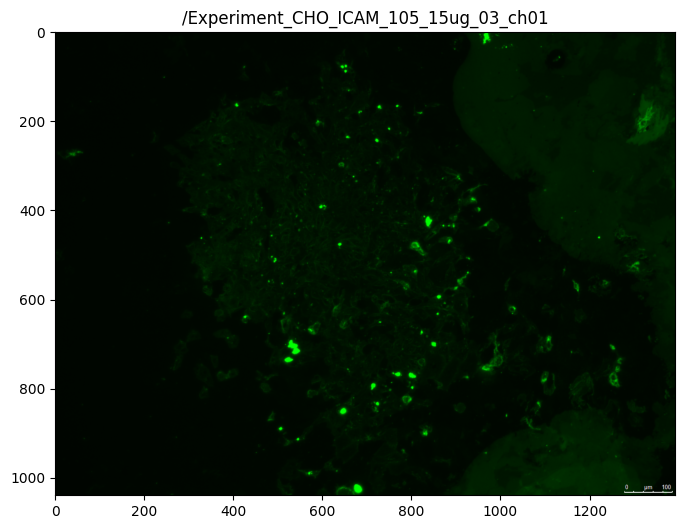

In [ ]:
path = lista_arquivos_vir_icam_fluo[12] #chamando a primeira imagem
img = Image.open(path) #abrinado a primeira imagem

plt.figure(figsize=(8,8)) #tamanho da imagem
plt.imshow(img) #abrindo a imagem
plt.title(path[50:-4]) #título recortando o nome do título que corresponde o caminho da imagem[50:-4]
plt.show()

In [ ]:
img_df = img_to_df(img=img) #chamando a função criada e como parâmetro está sendo passado a imagem organizada na pasta lá em cima.
img_df.head()

,red,green,blue
0,0.0,0.019608,0.0
1,0.0,0.019608,0.0
2,0.0,0.019608,0.0
3,0.0,0.023529,0.0
4,0.0,0.023529,0.0


In [ ]:
img_df_green = img_df['green'].copy() #copiando apenas a coluna verde da df original
freq = img_df_green.value_counts(normalize=True).to_frame().reset_index().sort_values('green', ascending=False)
#Acima: foi calculado a frequencia dos pixels na camada verde, convertido essa serie em DF, resetado index e organizado do maior para menor valor de pixel
freq

,green,proportion
39,1.000000,0.001166
131,0.996078,0.000032
111,0.992157,0.000046
124,0.988235,0.000037
134,0.984314,0.000030
...,...,...
0,0.027451,0.141837
1,0.023529,0.116533
25,0.019608,0.007677
237,0.015686,0.000006


In [ ]:
soma = 0 #igualando a variavel a 0
for n in range(len(freq)): #iteração para percorrer na df e somar os valores da coluna 1
  soma += freq.iloc[n,1]
  if soma >= 0.01: #5% dos dados
    print(soma)
    break
print(freq.iloc[n,:])

0.010014644120247562
green         0.231373
proportion    0.000365
Name: 54, dtype: float64


In [ ]:
img_df_vir_icam = img_df.copy()

In [ ]:
novo_valor = 0.0  # converter os valores em zero
img_df_vir_icam.loc[img_df_vir_icam['green'] >= 0.231373, 'green'] = novo_valor
img_df_vir_icam

,red,green,blue
0,0.0,0.019608,0.0
1,0.0,0.019608,0.0
2,0.0,0.019608,0.0
3,0.0,0.023529,0.0
4,0.0,0.023529,0.0
...,...,...,...
1447675,0.0,0.050980,0.0
1447676,0.0,0.062745,0.0
1447677,0.0,0.058824,0.0
1447678,0.0,0.058824,0.0


(0.0, 1.1)

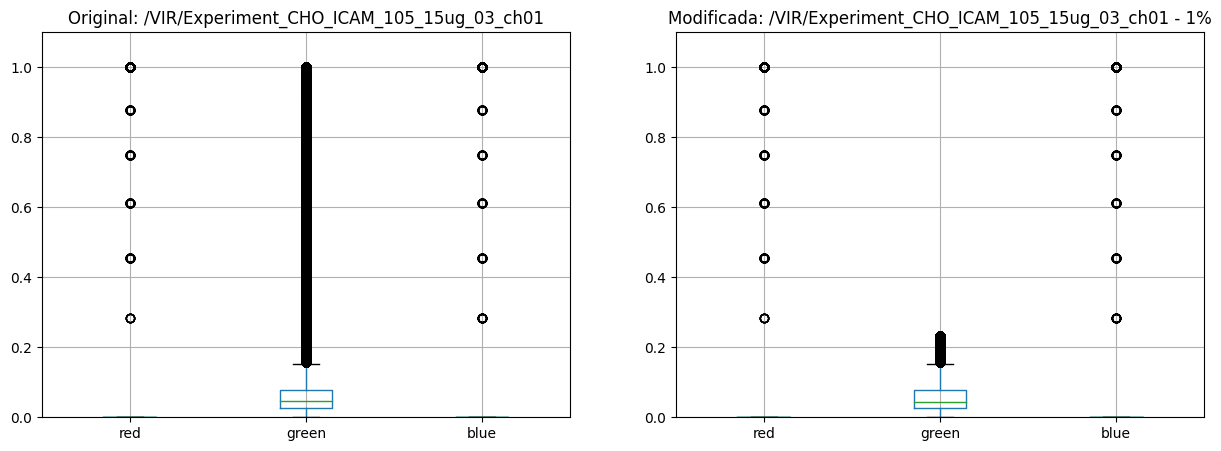

In [ ]:
plt.figure(figsize=(15,5))

plt.subplot(1, 2, 1)
plt.title(f"Original: {path[46:-4]}")
img_df.boxplot()
plt.ylim(0, maxplot())


plt.subplot(1, 2, 2)
plt.title(f"Modificada: {path[46:-4]} - 1%")
img_df_vir_icam.boxplot()
plt.ylim(0, maxplot())

Text(0.5, 1.0, 'Modificada: /VIR/Experiment_CHO_ICAM_105_15ug_03_ch01 - 1%')

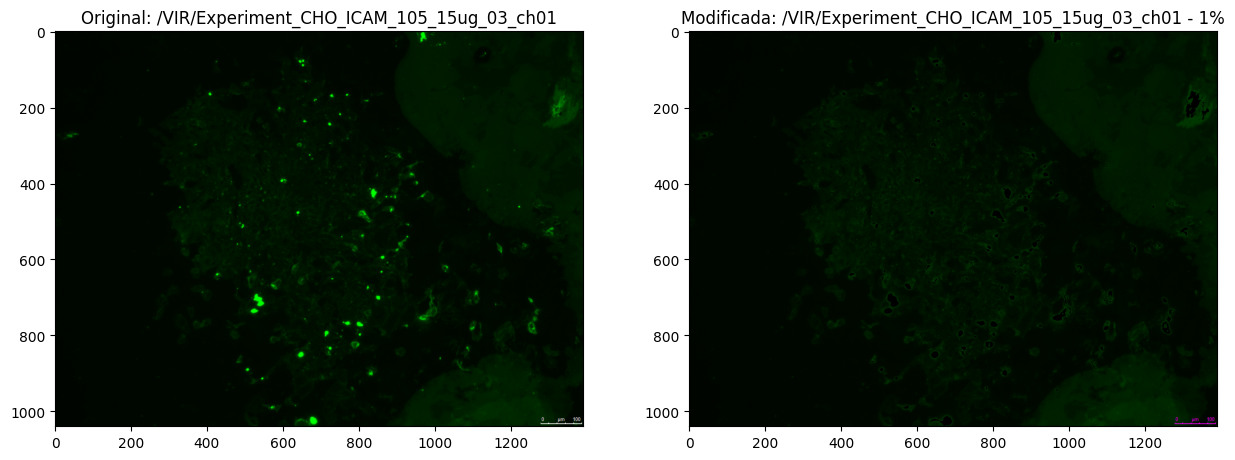

In [ ]:
plt.figure(figsize=(15,15))

plt.subplot(1, 2, 1)
plt.imshow(np.array(img_df).reshape(1040, 1392, 3))
plt.title(f"Original: {path[46:-4]}")

plt.subplot(1, 2, 2)
plt.imshow(np.array(img_df_vir_icam).reshape(1040, 1392, 3))
plt.title(f"Modificada: {path[46:-4]} - 1%")

In [ ]:
img_df_grupo = pd.DataFrame() #criando uma df
img_dict = {} #criando um dicionário

for path in lista_arquivos_vir_icam_fluo:  #laço para pasta o que tiver em lista de arquivos controle
  img = Image.open(path)              #abrinado a imagem que contem em path
  img_df_modif = img_df_vir_icam
  img_df_grupo[path[61:-4]] = img_df_modif['green'] #renomeando a coluna com o final do nome do ar arquivo e sustituindo a coluna green

  img_dict[path[61:-4]] = img_df_modif

img_df_grupo.head()

,_CHO_ICAM_105_10ug_01_ch01,_CHO_ICAM_105_10ug_02_ch01,_CHO_ICAM_105_10ug_03_ch01,_CHO_ICAM_105_10ug_04_ch01,_CHO_ICAM_105_10ug_05_ch01,_CHO_ICAM_105_10ug_06_ch01,_CHO_ICAM_105_10ug_07_ch01,_CHO_ICAM_105_10ug_08_ch01,_CHO_ICAM_105_10ug_09_ch01,_CHO_ICAM_105_10ug_10_ch01,...,_CHO_ICAM_105_5ug_03_ch01,_CHO_ICAM_105_5ug_04_ch01,_CHO_ICAM_105_5ug_05_ch01,_CHO_ICAM_105_5ug_06_ch01,_CHO_ICAM_105_5ug_07_ch01,_CHO_ICAM_105_5ug_08_ch01,_CHO_ICAM_105_5ug_09_ch01,_CHO_ICAM_105_5ug_10_ch01,_CHO_ICAM_105_5ug_11_ch01,_CHO_ICAM_105_5ug_12_ch01
0,0.019608,0.019608,0.019608,0.019608,0.019608,0.019608,0.019608,0.019608,0.019608,0.019608,...,0.019608,0.019608,0.019608,0.019608,0.019608,0.019608,0.019608,0.019608,0.019608,0.019608
1,0.019608,0.019608,0.019608,0.019608,0.019608,0.019608,0.019608,0.019608,0.019608,0.019608,...,0.019608,0.019608,0.019608,0.019608,0.019608,0.019608,0.019608,0.019608,0.019608,0.019608
2,0.019608,0.019608,0.019608,0.019608,0.019608,0.019608,0.019608,0.019608,0.019608,0.019608,...,0.019608,0.019608,0.019608,0.019608,0.019608,0.019608,0.019608,0.019608,0.019608,0.019608
3,0.023529,0.023529,0.023529,0.023529,0.023529,0.023529,0.023529,0.023529,0.023529,0.023529,...,0.023529,0.023529,0.023529,0.023529,0.023529,0.023529,0.023529,0.023529,0.023529,0.023529
4,0.023529,0.023529,0.023529,0.023529,0.023529,0.023529,0.023529,0.023529,0.023529,0.023529,...,0.023529,0.023529,0.023529,0.023529,0.023529,0.023529,0.023529,0.023529,0.023529,0.023529


In [ ]:
img_df_grupo.describe()

,_CHO_ICAM_105_10ug_01_ch01,_CHO_ICAM_105_10ug_02_ch01,_CHO_ICAM_105_10ug_03_ch01,_CHO_ICAM_105_10ug_04_ch01,_CHO_ICAM_105_10ug_05_ch01,_CHO_ICAM_105_10ug_06_ch01,_CHO_ICAM_105_10ug_07_ch01,_CHO_ICAM_105_10ug_08_ch01,_CHO_ICAM_105_10ug_09_ch01,_CHO_ICAM_105_10ug_10_ch01,...,_CHO_ICAM_105_5ug_03_ch01,_CHO_ICAM_105_5ug_04_ch01,_CHO_ICAM_105_5ug_05_ch01,_CHO_ICAM_105_5ug_06_ch01,_CHO_ICAM_105_5ug_07_ch01,_CHO_ICAM_105_5ug_08_ch01,_CHO_ICAM_105_5ug_09_ch01,_CHO_ICAM_105_5ug_10_ch01,_CHO_ICAM_105_5ug_11_ch01,_CHO_ICAM_105_5ug_12_ch01
count,1.447680e+06,1.447680e+06,1.447680e+06,1.447680e+06,1.447680e+06,1.447680e+06,1.447680e+06,1.447680e+06,1.447680e+06,1.447680e+06,...,1.447680e+06,1.447680e+06,1.447680e+06,1.447680e+06,1.447680e+06,1.447680e+06,1.447680e+06,1.447680e+06,1.447680e+06,1.447680e+06
mean,5.674318e-02,5.674318e-02,5.674318e-02,5.674318e-02,5.674318e-02,5.674318e-02,5.674318e-02,5.674318e-02,5.674318e-02,5.674318e-02,...,5.674318e-02,5.674318e-02,5.674318e-02,5.674318e-02,5.674318e-02,5.674318e-02,5.674318e-02,5.674318e-02,5.674318e-02,5.674318e-02
std,3.495427e-02,3.495427e-02,3.495427e-02,3.495427e-02,3.495427e-02,3.495427e-02,3.495427e-02,3.495427e-02,3.495427e-02,3.495427e-02,...,3.495427e-02,3.495427e-02,3.495427e-02,3.495427e-02,3.495427e-02,3.495427e-02,3.495427e-02,3.495427e-02,3.495427e-02,3.495427e-02
min,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,...,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
25%,2.745098e-02,2.745098e-02,2.745098e-02,2.745098e-02,2.745098e-02,2.745098e-02,2.745098e-02,2.745098e-02,2.745098e-02,2.745098e-02,...,2.745098e-02,2.745098e-02,2.745098e-02,2.745098e-02,2.745098e-02,2.745098e-02,2.745098e-02,2.745098e-02,2.745098e-02,2.745098e-02
50%,4.313725e-02,4.313725e-02,4.313725e-02,4.313725e-02,4.313725e-02,4.313725e-02,4.313725e-02,4.313725e-02,4.313725e-02,4.313725e-02,...,4.313725e-02,4.313725e-02,4.313725e-02,4.313725e-02,4.313725e-02,4.313725e-02,4.313725e-02,4.313725e-02,4.313725e-02,4.313725e-02
75%,7.843137e-02,7.843137e-02,7.843137e-02,7.843137e-02,7.843137e-02,7.843137e-02,7.843137e-02,7.843137e-02,7.843137e-02,7.843137e-02,...,7.843137e-02,7.843137e-02,7.843137e-02,7.843137e-02,7.843137e-02,7.843137e-02,7.843137e-02,7.843137e-02,7.843137e-02,7.843137e-02
max,2.313725e-01,2.313725e-01,2.313725e-01,2.313725e-01,2.313725e-01,2.313725e-01,2.313725e-01,2.313725e-01,2.313725e-01,2.313725e-01,...,2.313725e-01,2.313725e-01,2.313725e-01,2.313725e-01,2.313725e-01,2.313725e-01,2.313725e-01,2.313725e-01,2.313725e-01,2.313725e-01


#Chamando apenas as imagens dentro do CNTL ICAM:

In [ ]:
lista_arquivos_cont_icam = [i for i in lista_arquivos if "/Experiment_CHO_ICAM_cntl" in i]
lista_arquivos_cont_icam_fluo = [i for i in lista_arquivos_cont_icam if "ch01.tif" in i]
print(len(lista_arquivos_cont_icam_fluo))

25


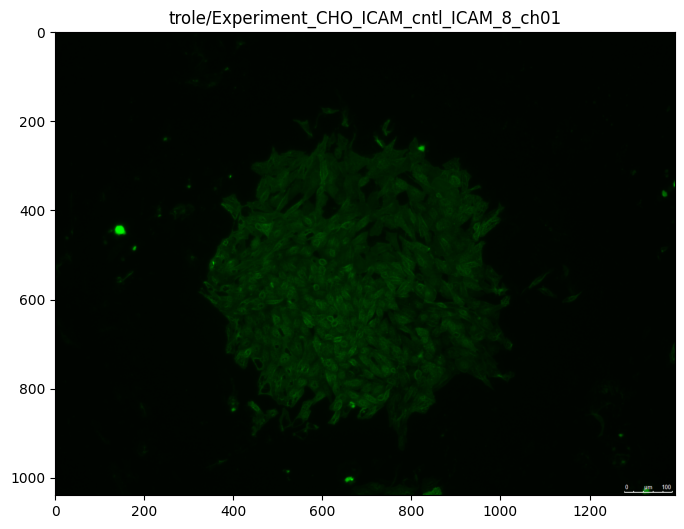

In [ ]:
path = lista_arquivos_cont_icam_fluo[12] #chamando a primeira imagem
img = Image.open(path) #abrinado a primeira imagem

plt.figure(figsize=(8,8)) #tamanho da imagem
plt.imshow(img) #abrindo a imagem
plt.title(path[50:-4]) #título recortando o nome do título que corresponde o caminho da imagem[50:-4]
plt.show()

In [ ]:
img_df = img_to_df(img=img) #chamando a função criada e como parâmetro está sendo passado a imagem organizada na pasta lá em cima.
img_df.head()

,red,green,blue
0,0.0,0.015686,0.0
1,0.0,0.015686,0.0
2,0.0,0.015686,0.0
3,0.0,0.015686,0.0
4,0.0,0.015686,0.0


In [ ]:
img_df_green = img_df['green'].copy() #copiando apenas a coluna verde da df original
freq = img_df_green.value_counts(normalize=True).to_frame().reset_index().sort_values('green', ascending=False)
#Acima: foi calculado a frequencia dos pixels na camada verde, convertido essa serie em DF, resetado index e organizado do maior para menor valor de pixel
freq

,green,proportion
63,1.000000,0.000244
141,0.996078,0.000006
139,0.992157,0.000006
128,0.988235,0.000006
110,0.984314,0.000010
...,...,...
2,0.023529,0.131979
0,0.019608,0.397784
1,0.015686,0.152490
55,0.011765,0.000670


In [ ]:
soma = 0 #igualando a variavel a 0
for n in range(len(freq)): #iteração para percorrer na df e somar os valores da coluna 1
  soma += freq.iloc[n,1]
  if soma >= 0.001: #5% dos dados
    print(soma)
    break
print(freq.iloc[n,:])

0.0010181808134394348
green         0.368627
proportion    0.000021
Name: 88, dtype: float64


In [ ]:
img_df_vir_crtl = img_df.copy()

In [ ]:
novo_valor = 0.0  # converter os valores em zero
img_df_vir_crtl.loc[img_df_vir_crtl['green'] >= 0.368627, 'green'] = novo_valor
img_df_vir_crtl

,red,green,blue
0,0.0,0.015686,0.0
1,0.0,0.015686,0.0
2,0.0,0.015686,0.0
3,0.0,0.015686,0.0
4,0.0,0.015686,0.0
...,...,...,...
1447675,0.0,0.015686,0.0
1447676,0.0,0.015686,0.0
1447677,0.0,0.015686,0.0
1447678,0.0,0.015686,0.0


(0.0, 1.1)

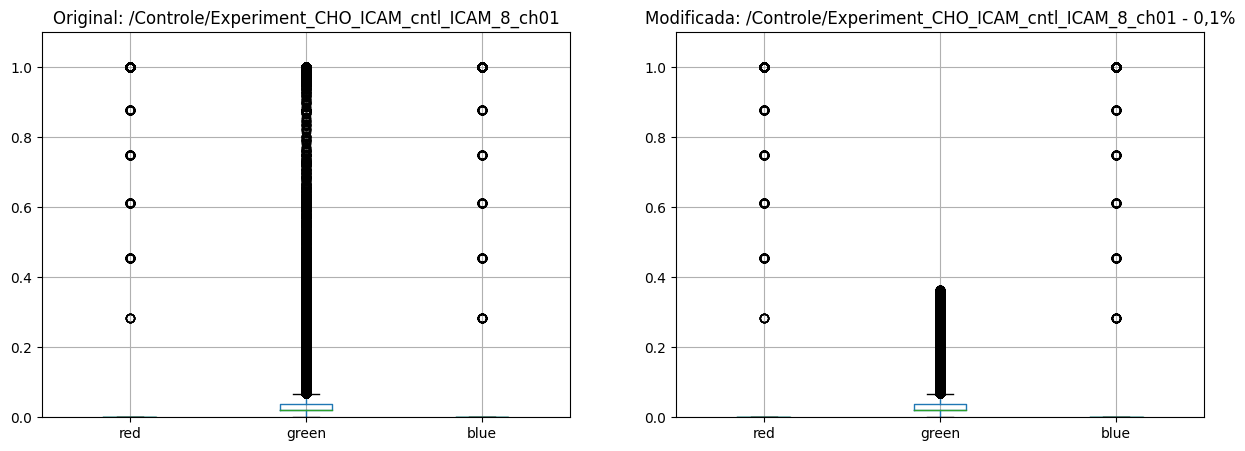

In [ ]:
plt.figure(figsize=(15,5))

plt.subplot(1, 2, 1)
plt.title(f"Original: {path[46:-4]}")
img_df.boxplot()
plt.ylim(0, maxplot())


plt.subplot(1, 2, 2)
plt.title(f"Modificada: {path[46:-4]} - 0,1%")
img_df_vir_crtl.boxplot()
plt.ylim(0, maxplot())

Text(0.5, 1.0, 'Modificada: /Controle/Experiment_CHO_ICAM_cntl_ICAM_8_ch01 - 0,1%')

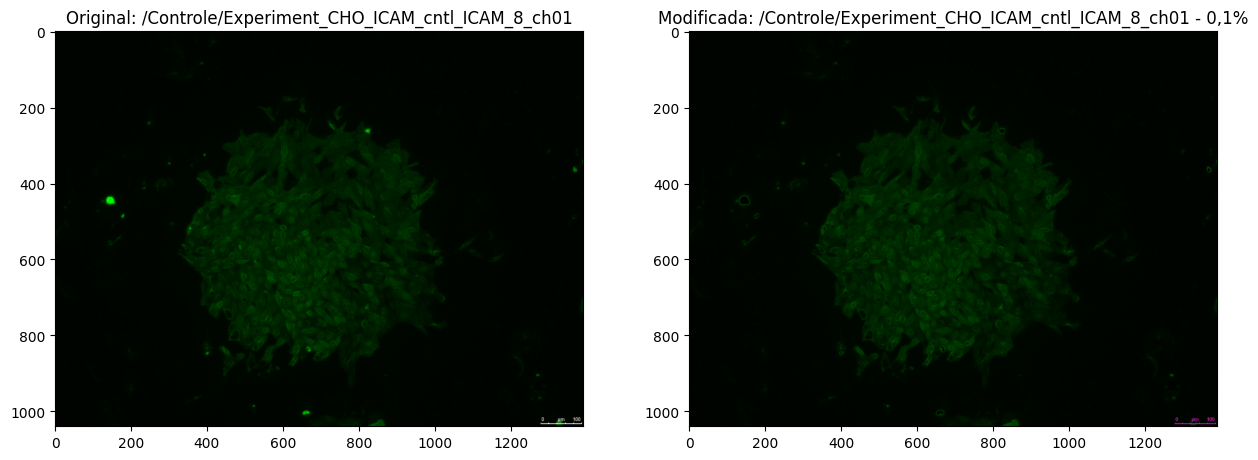

In [ ]:
plt.figure(figsize=(15,15))

plt.subplot(1, 2, 1)
plt.imshow(np.array(img_df).reshape(1040, 1392, 3))
plt.title(f"Original: {path[46:-4]}")

plt.subplot(1, 2, 2)
plt.imshow(np.array(img_df_vir_crtl).reshape(1040, 1392, 3))
plt.title(f"Modificada: {path[46:-4]} - 0,1%")

In [ ]:
img_df_grupo = pd.DataFrame() #criando uma df
img_dict = {} #criando um dicionário

for path in lista_arquivos_cont_icam_fluo:  #laço para pasta o que tiver em lista de arquivos controle
  img = Image.open(path)              #abrinado a imagem que contem em path
  img_df_modif = img_df_vir_crtl
  img_df_grupo[path[61:-4]] = img_df_modif['green'] #renomeando a coluna com o final do nome do ar arquivo e sustituindo a coluna green

  img_dict[path[67:-11]] = img_df_modif


img_df_grupo.head()

,iment_CHO_ICAM_cntl_cel_1_ch01,iment_CHO_ICAM_cntl_cel_2_ch01,iment_CHO_ICAM_cntl_cel_3_ch01,iment_CHO_ICAM_cntl_cel_4_ch01,iment_CHO_ICAM_cntl_ICAM_10_ch01,iment_CHO_ICAM_cntl_ICAM_1_ch01,iment_CHO_ICAM_cntl_ICAM_2_ch01,iment_CHO_ICAM_cntl_ICAM_3_ch01,iment_CHO_ICAM_cntl_ICAM_4_ch01,iment_CHO_ICAM_cntl_ICAM_5_ch01,...,iment_CHO_ICAM_cntl_sec_Mouse_2_ch01,iment_CHO_ICAM_cntl_sec_Mouse_3_ch01,iment_CHO_ICAM_cntl_sec_Mouse_4_ch01,iment_CHO_ICAM_cntl_sec_Rabbit_1_ch01,iment_CHO_ICAM_cntl_sec_Rabbit_2_ch01,iment_CHO_ICAM_cntl_sec_Rabbit_3_ch01,iment_CHO_ICAM_cntl_sec_Rabbit_4_ch01,iment_CHO_ICAM_cntl_sec_Rabbit_6_ch01,iment_CHO_ICAM_cntl_sec_Rabbit_7_ch01,iment_CHO_ICAM_cntl_sec_Rabbit_8_ch01
0,0.015686,0.015686,0.015686,0.015686,0.015686,0.015686,0.015686,0.015686,0.015686,0.015686,...,0.015686,0.015686,0.015686,0.015686,0.015686,0.015686,0.015686,0.015686,0.015686,0.015686
1,0.015686,0.015686,0.015686,0.015686,0.015686,0.015686,0.015686,0.015686,0.015686,0.015686,...,0.015686,0.015686,0.015686,0.015686,0.015686,0.015686,0.015686,0.015686,0.015686,0.015686
2,0.015686,0.015686,0.015686,0.015686,0.015686,0.015686,0.015686,0.015686,0.015686,0.015686,...,0.015686,0.015686,0.015686,0.015686,0.015686,0.015686,0.015686,0.015686,0.015686,0.015686
3,0.015686,0.015686,0.015686,0.015686,0.015686,0.015686,0.015686,0.015686,0.015686,0.015686,...,0.015686,0.015686,0.015686,0.015686,0.015686,0.015686,0.015686,0.015686,0.015686,0.015686
4,0.015686,0.015686,0.015686,0.015686,0.015686,0.015686,0.015686,0.015686,0.015686,0.015686,...,0.015686,0.015686,0.015686,0.015686,0.015686,0.015686,0.015686,0.015686,0.015686,0.015686


In [ ]:
img_df_grupo.describe()

,CHO_ICAM_cntl_cel,CHO_ICAM_cntl_ICAM_,CHO_ICAM_cntl_ICAM,CHO_ICAM_cntl_sec_Mouse,CHO_ICAM_cntl_sec_Rabbit
count,1.447680e+06,1.447680e+06,1.447680e+06,1.447680e+06,1.447680e+06
mean,4.601302e-02,4.601302e-02,4.601302e-02,4.601302e-02,4.601302e-02
std,5.019052e-02,5.019052e-02,5.019052e-02,5.019052e-02,5.019052e-02
min,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
25%,1.960784e-02,1.960784e-02,1.960784e-02,1.960784e-02,1.960784e-02
50%,1.960784e-02,1.960784e-02,1.960784e-02,1.960784e-02,1.960784e-02
75%,3.921569e-02,3.921569e-02,3.921569e-02,3.921569e-02,3.921569e-02
max,3.647059e-01,3.647059e-01,3.647059e-01,3.647059e-01,3.647059e-01


In [ ]:
img_df_grupo.sum().mean()

66612.12549019608

In [ ]:
img_df_grupo.sum().median()

66612.12549019608

<Axes: >

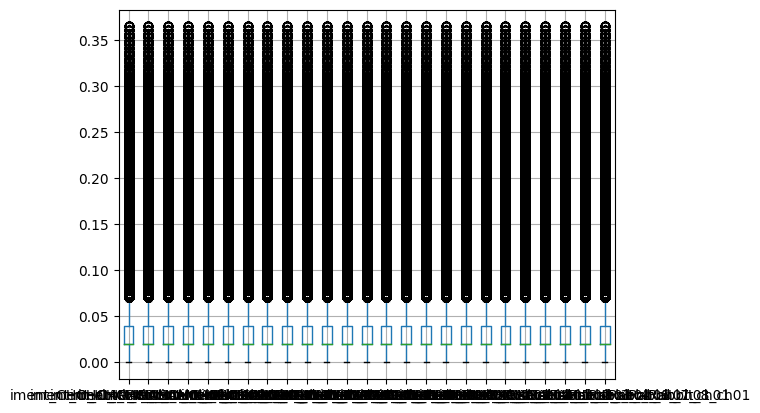

In [ ]:
img_df_grupo.boxplot()

In [ ]:
import seaborn as sns


In [ ]:
# plt.figure(figsize=(20, 6))
# sns.boxplot(data= img_df_grupo)
# #plt.title('Boxplot de várias colunas')
# plt.xlabel('Colunas')
# plt.ylabel('Valores')
# plt.show()

NameError: name 'plt' is not defined